# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats # scipy - Scienctific Python

# Create Data Set

In [5]:
np.random.seed(42) # Random dataset is generted , seed - random value is fixed
data = {
    'product_id' : range(1,21),
    'product_name' : [f'Product(i)' for i in range (1,21)],
    'category' : np.random.choice(['Electronics','Clothing','Home','Sports'],20),
    'units_sold' : np.random.poisson(lam = 20, size =20),
    'sales_date' : pd.date_range(start='2026-01-01',periods =20, freq= 'D')
}
                                 
            
sales_data = pd.DataFrame(data)
print(sales_data)
# lam = 20 -- Lambda is the average of expectef value
# The average units sold is expected to be around 20

    product_id product_name     category  units_sold sales_date
0            1   Product(i)         Home          25 2026-01-01
1            2   Product(i)       Sports          15 2026-01-02
2            3   Product(i)  Electronics          17 2026-01-03
3            4   Product(i)         Home          19 2026-01-04
4            5   Product(i)         Home          21 2026-01-05
5            6   Product(i)       Sports          17 2026-01-06
6            7   Product(i)  Electronics          19 2026-01-07
7            8   Product(i)  Electronics          16 2026-01-08
8            9   Product(i)         Home          21 2026-01-09
9           10   Product(i)     Clothing          21 2026-01-10
10          11   Product(i)         Home          17 2026-01-11
11          12   Product(i)         Home          22 2026-01-12
12          13   Product(i)         Home          14 2026-01-13
13          14   Product(i)         Home          17 2026-01-14
14          15   Product(i)       Sports

In [6]:
sales_data.to_csv('sales_data.csv',index=False)

In [7]:
import os
os.getcwd()

'/Users/sathvikgattu/anaconda_projects/Full Stack Data Science , Adv GenAI and AgenticAI'

# Descriptive Stats

In [8]:
descriptive_stats = sales_data['units_sold'].describe()
print(descriptive_stats) # Descriptive stats for units sold

count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64


In [12]:
# Mean , Median , Mode , Variance , STD
mean_ds = sales_data['units_sold'].mean()
median_ds = sales_data['units_sold'].median()
mode_ds = sales_data['units_sold'].mode()
var_ds = sales_data['units_sold'].var()
std_ds = sales_data['units_sold'].std()

In [18]:
# Grouping categorical column and Calculate total and avgerage sales
category_stats = sales_data.groupby('category')['units_sold'].agg(['sum', 'mean', 'std'])
print('\nStatistical Analysis: ')
print(f'Mean Units Sold: {mean_ds}')
print(f'Median Units Sold: {median_ds}')
print(f'Mode Units Sold: {mode_ds}')
print(f'Varience Units Sold: {var_ds}')
print(f'Std Devaition Units Sold: {std_ds}')
print('\nCategory Statistics')
print(category_stats)



Statistical Analysis: 
Mean Units Sold: 18.8
Median Units Sold: 18.5
Mode Units Sold: 0    17
1    21
Name: units_sold, dtype: int64
Varience Units Sold: 10.90526315789474
Std Devaition Units Sold: 3.3023117899275864

Category Statistics
             sum       mean       std
category                             
Clothing      21  21.000000       NaN
Electronics   73  18.250000  2.217356
Home         181  20.111111  3.723051
Sports       101  16.833333  2.714160


# Inferential Stats 

In [20]:
# Calculating Confidence Interval
confidence_level = 0.95 # (95%)
degrees_freedom = len(sales_data['units_sold']) - 1
sample_mean = mean_ds
sample_std_error = std_ds / np.sqrt(len(sales_data['units_sold']))

# t-score for confidence level
t_score = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
margin_of_error = t_score * sample_std_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print('\nConfidence Interval for Mean of Units Sold:')
print(confidence_interval)


Confidence Interval for Mean of Units Sold:
(np.float64(17.254470507823573), np.float64(20.34552949217643))


In [24]:
# Hypothesis Testing
t_statistics, p_value = stats.ttest_1samp(sales_data['units_sold'], 20)
print('\nHypothesis Testing (t-test): ')
print(f'T-statistics: {t_statistics}, P-value: {p_value}')
if p_value < 0.05:
    print('Reject the null hypothesis: The mean units sold is significantly different from 20')
else:
    print('Fail reject the null hypothesis: The units sold is not significantly different from predicted')


Hypothesis Testing (t-test): 
T-statistics: -1.6250928099424466, P-value: 0.12061572226781002
Fail reject the null hypothesis: The units sold is not significantly different from predicted


# Visualizations

In [29]:
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

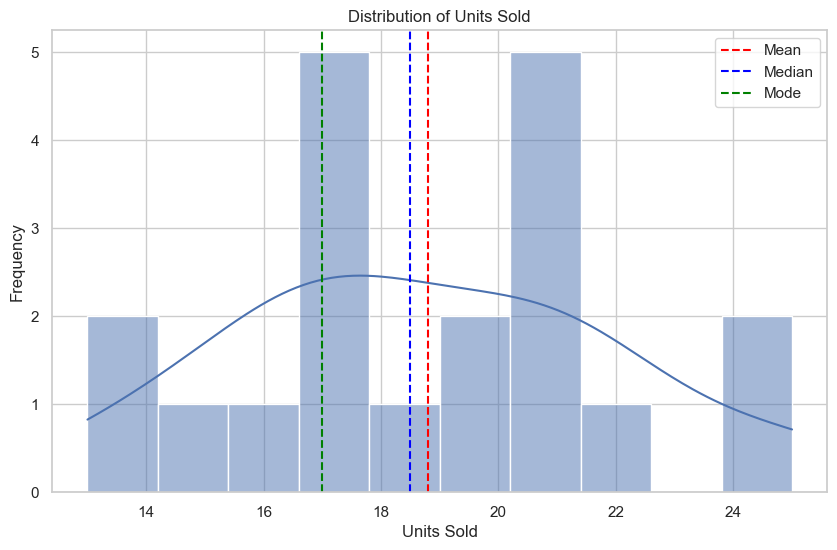

<Figure size 200x100 with 0 Axes>

<Figure size 200x100 with 0 Axes>

In [34]:
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.histplot(sales_data['units_sold'], bins=10, kde=True)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.axvline(mean_ds, color='red', linestyle='--', label='Mean')
plt.axvline(median_ds, color='blue', linestyle='--', label='Median')
plt.axvline(sales_data['units_sold'].mode()[0], color='green', linestyle='--', label='Mode')

plt.legend()
plt.show()
plt.figure(figsize=(2,1))

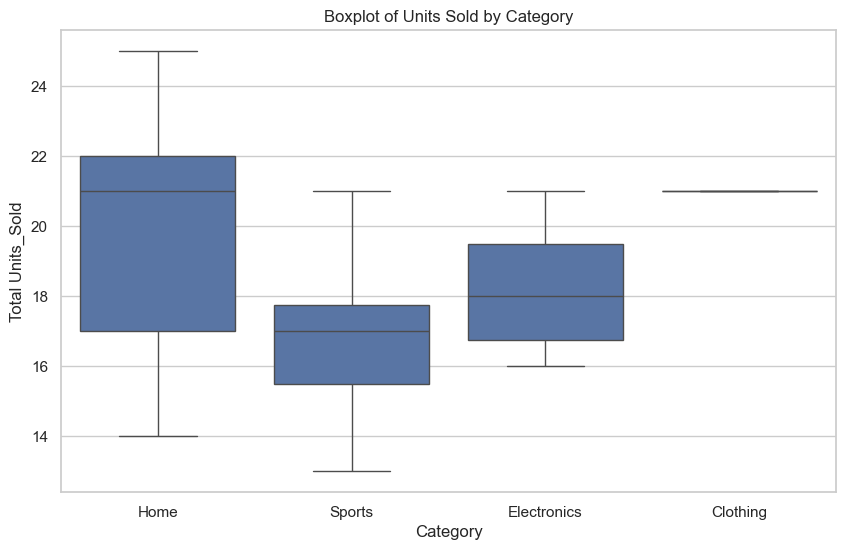

In [36]:
# Box plot
plt.figure(figsize = (10,6))
sns.boxplot(x = 'category', y = 'units_sold', data = sales_data)
plt.title('Boxplot of Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units_Sold')
plt.show()

In [ ]:
# Ba